Weather Classification Using Deep Learning






In [ ]:
#cell 1
!pip install -q kaggle

In [ ]:
#cell 2 Import Libraries
import kagglehub
import shutil
import os

save_path = "/content/all_datasets"
os.makedirs(save_path, exist_ok=True)

datasets = [
    "jehanbhathena/weather-dataset",
    "ammaralfaifi/5class-weather-status-image-classification",
    "somesh24/multiclass-images-for-weather-classification",
    "tamimresearch/weather-image-dataset",
    "solesensei/solesensei_bdd100k"
]

for data in datasets:
    path = kagglehub.dataset_download(data)
    folder_name = data.split("/")[0]
    shutil.copytree(path, f"{save_path}/{folder_name}", dirs_exist_ok=True)
    print("Done:", data)

100%|██████████| 587M/587M [00:05<00:00, 122MB/s]

Extracting files...


Done: jehanbhathena/weather-dataset


100%|██████████| 498M/498M [00:06<00:00, 77.5MB/s]


Extracting files...
Done: ammaralfaifi/5class-weather-status-image-classification


...

Extracting files...


Done: somesh24/multiclass-images-for-weather-classification


100%|██████████| 246M/246M [00:02<00:00, 92.3MB/s]

Extracting files...


Done: tamimresearch/weather-image-dataset
Using Colab cache for faster access to the 'solesensei_bdd100k' dataset.
Done: solesensei/solesensei_bdd100k


In [ ]:
#cell 3 Create Class Folders
import os

classes = [
    "Sunny","Cloudy","Rainy","Foggy",
    "Snowy","Dusty","Stormy","Other"
]

base = "/content/weather_final"

for c in classes:
    os.makedirs(os.path.join(base,c), exist_ok=True)

print("Done")

Done


In [ ]:
#cell 4 Data Collection and Merging
import os, shutil

dst = "/content/weather_final"

sources = [
    ("/content/all_datasets/ammaralfaifi/data", {
        "sunny":"Sunny","cloudy":"Cloudy","rainy":"Rainy","foggy":"Foggy","snowy":"Snowy"
    }),

    ("/content/all_datasets/jehanbhathena/dataset", {
        "rain":"Rainy","fogsmog":"Foggy","snow":"Snowy","sandstorm":"Dusty","lightning":"Stormy"
    }),

    ("/content/all_datasets/tamimresearch", {
        "cloudy":"Cloudy","rainy":"Rainy","foggy":"Foggy","sandstorm":"Dusty","lightning":"Stormy"
    })
]

for src, mapping in sources:
    for old,new in mapping.items():
        folder = os.path.join(src, old)
        if os.path.exists(folder):
            for file in os.listdir(folder):
                shutil.copy(os.path.join(folder,file),
                            os.path.join(dst,new,file))

# somesh24
src = "/content/all_datasets/somesh24/dataset2"

for file in os.listdir(src):
    name = file.lower()

    if name.startswith("rain"):
        target = "Rainy"
    elif name.startswith("shine") or name.startswith("sunrise"):
        target = "Sunny"
    else:
        target = "Other"

    shutil.copy(os.path.join(src,file),
                os.path.join(dst,target,file))

print("Done")

Done


In [ ]:
#cell 5 Check Number of Images in Each Class
import os

base = "/content/weather_final"

for folder in sorted(os.listdir(base)):
    count = len(os.listdir(os.path.join(base, folder)))
    print(folder, ":", count)

Cloudy : 7052
Dusty : 1092
Foggy : 1919
Other : 300
Rainy : 2349
Snowy : 1901
Stormy : 777
Sunny : 6671


In [ ]:
#cell 6 Balance Dataset Using Data Augmentation
import os, random, shutil
from PIL import Image, ImageOps

base = "/content/weather_final"
target = 4000

for cls in os.listdir(base):
    path = os.path.join(base, cls)
    files = os.listdir(path)

    if len(files) < target:
        need = target - len(files)

        for i in range(need):
            img_name = random.choice(files)
            img_path = os.path.join(path, img_name)

            img = Image.open(img_path).convert("RGB")

            if i % 2 == 0:
                img = ImageOps.mirror(img)
            else:
                img = ImageOps.flip(img)

            new_name = f"aug_{i}_{img_name}"
            img.save(os.path.join(path, new_name))

print("Done")

Done


In [ ]:
#cell 7  Split Dataset into Train / Validation / Test
!pip install -q split-folders

import splitfolders

splitfolders.ratio(
    "/content/weather_final",
    output="/content/weather_split",
    seed=42,
    ratio=(0.7,0.2,0.1)
)

print("Done")

Copying files: 37723 files [00:14, 2551.76 files/s]

Done


In [ ]:
#cell 8 Verify Train / Validation / Test Distribution
import os

base = "/content/weather_split"

for part in ["train", "val", "test"]:
    print("\n", part.upper())
    for cls in sorted(os.listdir(os.path.join(base, part))):
        count = len(os.listdir(os.path.join(base, part, cls)))
        print(cls, ":", count)


 TRAIN
Cloudy : 4936
Dusty : 2800
Foggy : 2800
Other : 2800
Rainy : 2800
Snowy : 2800
Stormy : 2800
Sunny : 4669

 VAL
Cloudy : 1410
Dusty : 800
Foggy : 800
Other : 800
Rainy : 800
Snowy : 800
Stormy : 800
Sunny : 1334

 TEST
Cloudy : 706
Dusty : 400
Foggy : 400
Other : 400
Rainy : 400
Snowy : 400
Stormy : 400
Sunny : 668


In [ ]:
#cell 9 Remove Corrupted Images from Dataset
import os
from PIL import Image

base = "/content/weather_split"
bad = 0

for root, dirs, files in os.walk(base):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            img.verify()
        except:
            os.remove(path)
            bad += 1

print("Deleted:", bad, "corrupted files")

requirements: Ultralytics requirement ['pi-heif'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 446ms
Prepared 1 package in 83ms
Installed 1 package in 5ms
 + pi-heif==1.3.0

requirements: AutoUpdate success ✅ 2.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Deleted: 2 corrupted files


In [ ]:
#cell 10 Load Train / Validation / Test Datasets
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

img_size = (160,160)
batch = 32
num_classes = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/weather_split/train",
    image_size=img_size,
    batch_size=batch,
    shuffle=True
).ignore_errors()

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/weather_split/val",
    image_size=img_size,
    batch_size=batch
).ignore_errors()

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/weather_split/test",
    image_size=img_size,
    batch_size=batch,
    shuffle=False
).ignore_errors()

base_model = MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

model.save("/content/weather_model.keras")

Found 26405 files belonging to 8 classes.
Found 7544 files belonging to 8 classes.
Found 3774 files belonging to 8 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
    783/Unknown 543s 685ms/step - accuracy: 0.5840 - loss: 1.1193

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


783/783 ━━━━━━━━━━━━━━━━━━━━ 692s 876ms/step - accuracy: 0.6689 - loss: 0.8653 - val_accuracy: 0.7612 - val_loss: 0.5957
Epoch 2/3
783/783 ━━━━━━━━━━━━━━━━━━━━ 741s 947ms/step - accuracy: 0.7495 - loss: 0.6402 - val_accuracy: 0.7837 - val_loss: 0.5491
Epoch 3/3
783/783 ━━━━━━━━━━━━━━━━━━━━ 662s 846ms/step - accuracy: 0.7644 - loss: 0.6007 - val_accuracy: 0.7710 - val_loss: 0.5495
116/116 ━━━━━━━━━━━━━━━━━━━━ 78s 670ms/step - accuracy: 0.7728 - loss: 0.5418
Test Accuracy: 0.7727763056755066


In [ ]:
#cell 11 Fine-Tune MobileNetV2 for Better Accuracy
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
784/784 ━━━━━━━━━━━━━━━━━━━━ 913s 1s/step - accuracy: 0.7132 - loss: 0.7593 - val_accuracy: 0.7984 - val_loss: 0.5158
Epoch 2/5
784/784 ━━━━━━━━━━━━━━━━━━━━ 883s 1s/step - accuracy: 0.7846 - loss: 0.5546 - val_accuracy: 0.8298 - val_loss: 0.4425
Epoch 3/5
784/784 ━━━━━━━━━━━━━━━━━━━━ 884s 1s/step - accuracy: 0.8165 - loss: 0.4740 - val_accuracy: 0.8487 - val_loss: 0.3980
Epoch 4/5
784/784 ━━━━━━━━━━━━━━━━━━━━ 885s 1s/step - accuracy: 0.8429 - loss: 0.4132 - val_accuracy: 0.8607 - val_loss: 0.3682
Epoch 5/5
784/784 ━━━━━━━━━━━━━━━━━━━━ 887s 1s/step - accuracy: 0.8576 - loss: 0.3700 - val_accuracy: 0.8682 - val_loss: 0.3508


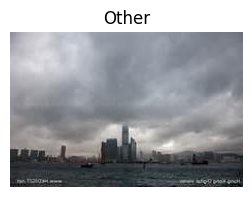

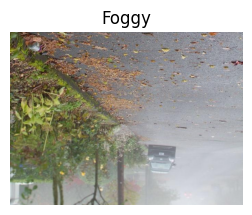

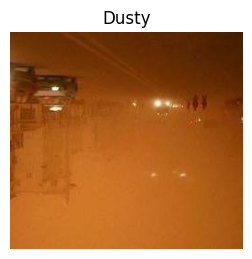

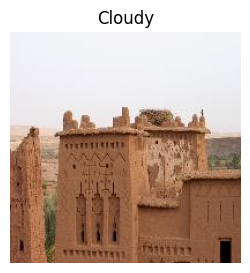

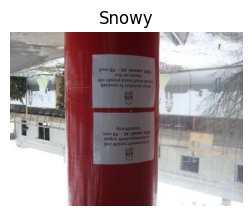

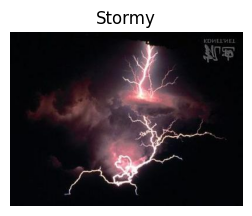

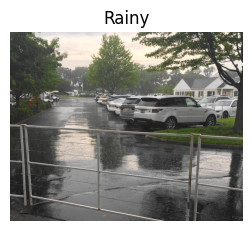

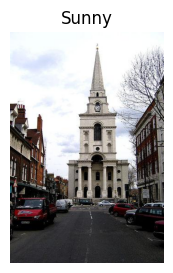

In [ ]:
#cell 12 Show Random Sample Image from Each Class
import os, random
import matplotlib.pyplot as plt
from PIL import Image

base = "/content/weather_split/test"

classes = os.listdir(base)

for cls in classes:
    folder = os.path.join(base, cls)
    img_name = random.choice(os.listdir(folder))
    img = Image.open(os.path.join(folder, img_name))

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    plt.show()

In [ ]:
#cell 13 Final Model Evaluation
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

116/116 ━━━━━━━━━━━━━━━━━━━━ 77s 660ms/step - accuracy: 0.8652 - loss: 0.3512
Test Accuracy: 0.8652291297912598


In [ ]:
# cell 14 Save Final Trained Model
model.save("/content/weather_final_model.keras")
print("Saved")

Saved


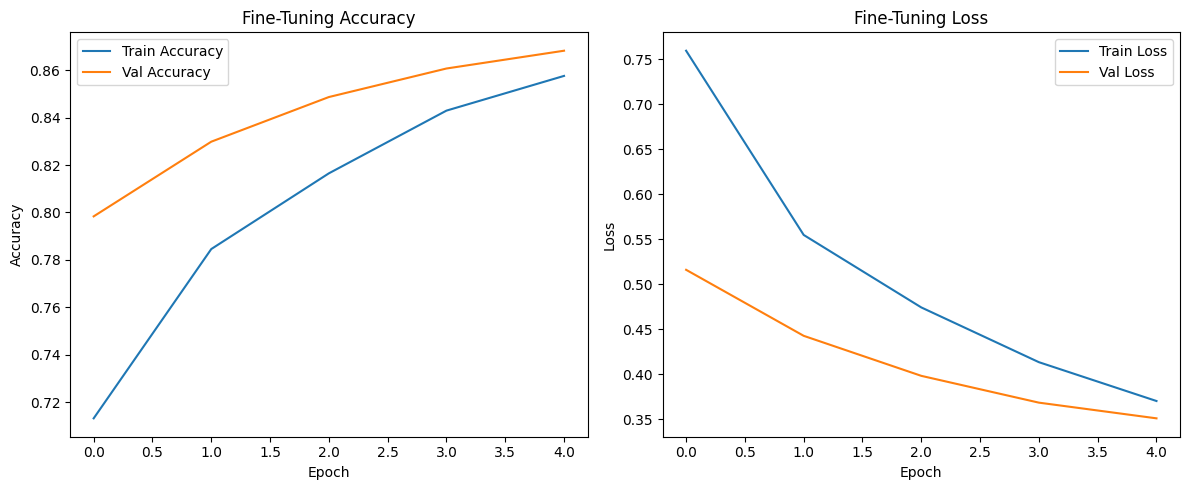

In [ ]:
#cell 15 Plot Fine-Tuning Accuracy and Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.title('Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


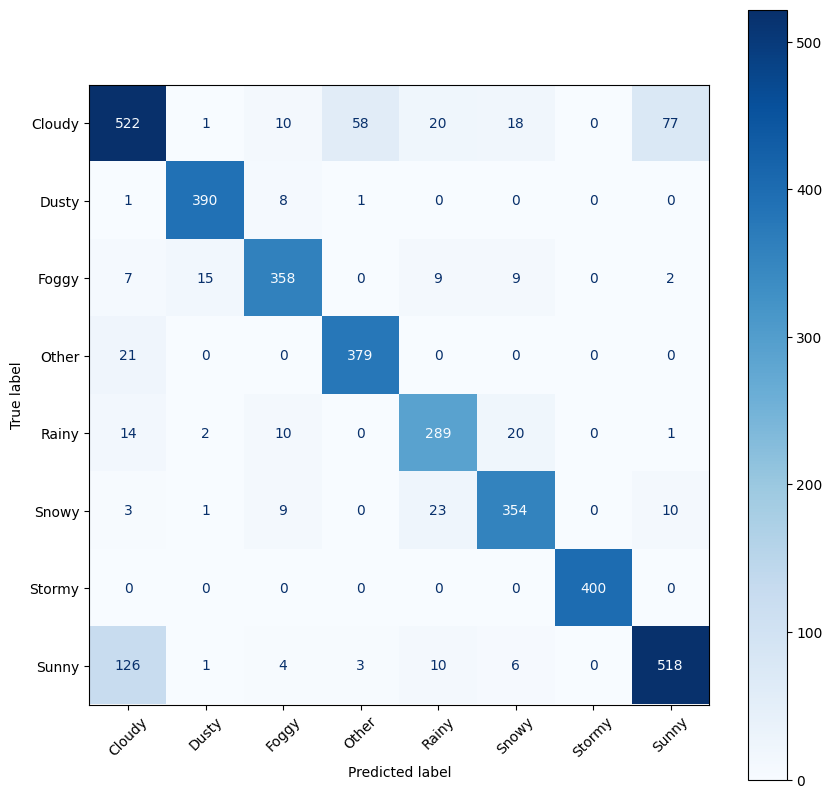

In [ ]:
#cell 16 Plot Confusion Matrix for Final Model
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.concatenate([y for x, y in test_ds], axis=0)

pred = model.predict(test_ds, verbose=0)
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Cloudy','Dusty','Foggy','Other','Rainy','Snowy','Stormy','Sunny']
)

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.show()

In [ ]:
#cell 17 Generate Classification Report for Final Model
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Cloudy','Dusty','Foggy','Other','Rainy','Snowy','Stormy','Sunny']
))

              precision    recall  f1-score   support

      Cloudy       0.75      0.74      0.75       706
       Dusty       0.95      0.97      0.96       400
       Foggy       0.90      0.90      0.90       400
       Other       0.86      0.95      0.90       400
       Rainy       0.82      0.86      0.84       336
       Snowy       0.87      0.89      0.88       400
      Stormy       1.00      1.00      1.00       400
       Sunny       0.85      0.78      0.81       668

    accuracy                           0.87      3710
   macro avg       0.88      0.88      0.88      3710
weighted avg       0.86      0.87      0.86      3710



In [ ]:
#cell 18
from google.colab import files
from tensorflow.keras.models import load_model

files.upload()

model = load_model("weather_final_model (1).keras")
print("Model Loaded Successfully")

Saving weather_final_model (1).keras to weather_final_model (1).keras
Model Loaded Successfully


In [ ]:
#cell 19 Demo: Predict Weather from Uploaded Image
from google.colab import files
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()

image_name = list(uploaded.keys())[0]
image_path = "/content/" + image_name

image = load_img(image_path, target_size=(160,160))
image_array = img_to_array(image)
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array, verbose=0)

classes = ['Cloudy','Dusty','Foggy','Other','Rainy','Snowy','Stormy','Sunny']

result = classes[np.argmax(prediction)]
confidence = float(np.max(prediction)) * 100

advice = {
    "Sunny": "Good weather for going outside.",
    "Cloudy": "Suitable for going outside.",
    "Rainy": "Take an umbrella.",
    "Foggy": "Drive carefully.",
    "Dusty": "Better to stay indoors.",
    "Stormy": "Not recommended to go outside.",
    "Snowy": "Wear heavy clothes.",
    "Other": "Check weather conditions first."
}

print("=" * 40)
print("Weather Prediction Result")
print("=" * 40)
print(f"Image Name      : {image_name}")
print(f"Predicted Class : {result}")
print(f"Confidence      : {confidence:.2f}%")
print(f"Recommendation  : {advice[result]}")
print("=" * 40)

Saving OIP (5).webp to OIP (5).webp
Weather Prediction Result
Image Name      : OIP (5).webp
Predicted Class : Sunny
Confidence      : 92.74%
Recommendation  : Good weather for going outside.
